# **Importing libraries**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
import dice_ml
from dice_ml import Dice
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier

In [71]:
# Added display settings to make it easier to inspect all columns and full outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# **Data preparation**

In [73]:
data = pd.read_csv("dataset.csv")

In [74]:
data.head() # Check the first rows

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [75]:
data.info() # Check structure and whether cleaning is needed

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [76]:
data.rename(columns = {"Nacionality":"Nationality"}, inplace = True) # Fixed a spelling mistake

In [77]:
data.isnull().sum()/len(data)*100 # Check percentage of missing values

Marital status                                    0.0
Application mode                                  0.0
Application order                                 0.0
Course                                            0.0
Daytime/evening attendance                        0.0
Previous qualification                            0.0
Nationality                                       0.0
Mother's qualification                            0.0
Father's qualification                            0.0
Mother's occupation                               0.0
Father's occupation                               0.0
Displaced                                         0.0
Educational special needs                         0.0
Debtor                                            0.0
Tuition fees up to date                           0.0
Gender                                            0.0
Scholarship holder                                0.0
Age at enrollment                                 0.0
International               

In [78]:
data.duplicated().sum()/len(data)*100 # Check percentage of duplicated values

0.0

In [79]:
data.describe().T # Summary statistics 

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nationality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


In [80]:
print(data["Target"].value_counts()) # Check target class distribution before filtering

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [81]:
# Keep only Dropout and Graduate
data = data[data["Target"].isin(["Dropout", "Graduate"])].copy()

# Binary encoding
data["Target"] = data["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

print(data["Target"].value_counts())

Target
0    2209
1    1421
Name: count, dtype: int64


# **Train-test split**

In [83]:
# Split features and target
X = data.drop(columns=["Target"])
y = data["Target"]
print(X.shape)
print(y.shape)

(3630, 34)
(3630,)


In [84]:
# Make a 80/20 train-test split which accounts for imbalanced classes using stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2904, 34)
Test shape: (726, 34)


# **Train a model**

In [86]:
# Train Random Forest model with a balanced class weight to compensate for class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [87]:
# Evaluate predictive performance
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.928374655647383
ROC-AUC: 0.9693255687973998

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



# **SHAP**

In [89]:
explainer = shap.Explainer(rf_model, X_train) # Initialize SHAP explainer for tree-based model
shap_values = explainer(X_test) # Compute SHAP values for test set

 97%|=================== | 1412/1452 [00:24<00:00]       

In [90]:
print(shap_values.shape)

(726, 34, 2)


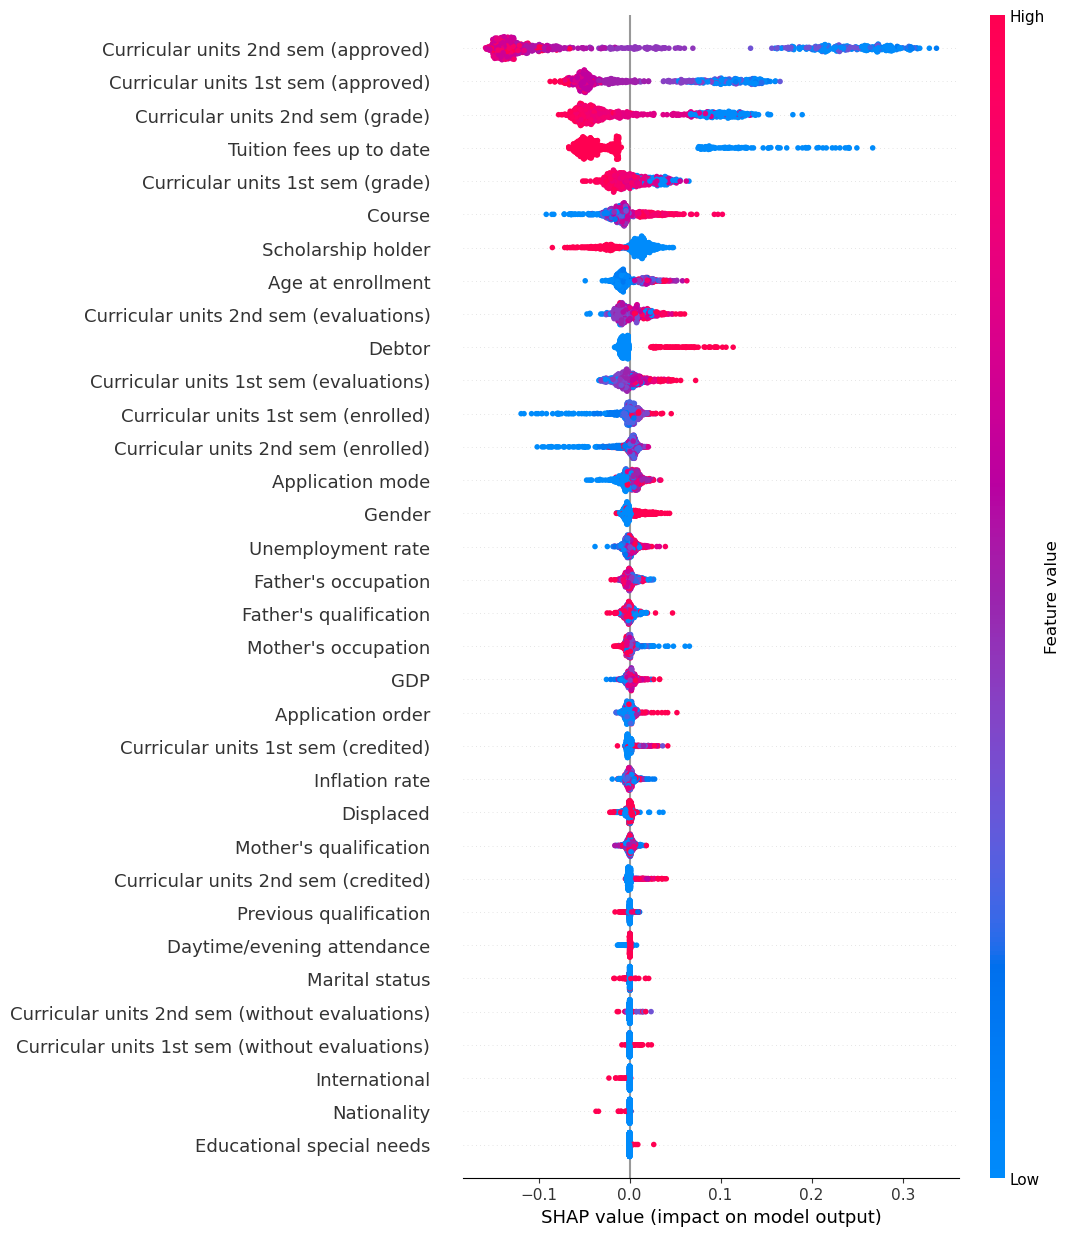

In [91]:
shap.plots.beeswarm(shap_values[:, :, 1], max_display=34) # Make beeswarm plot of all features

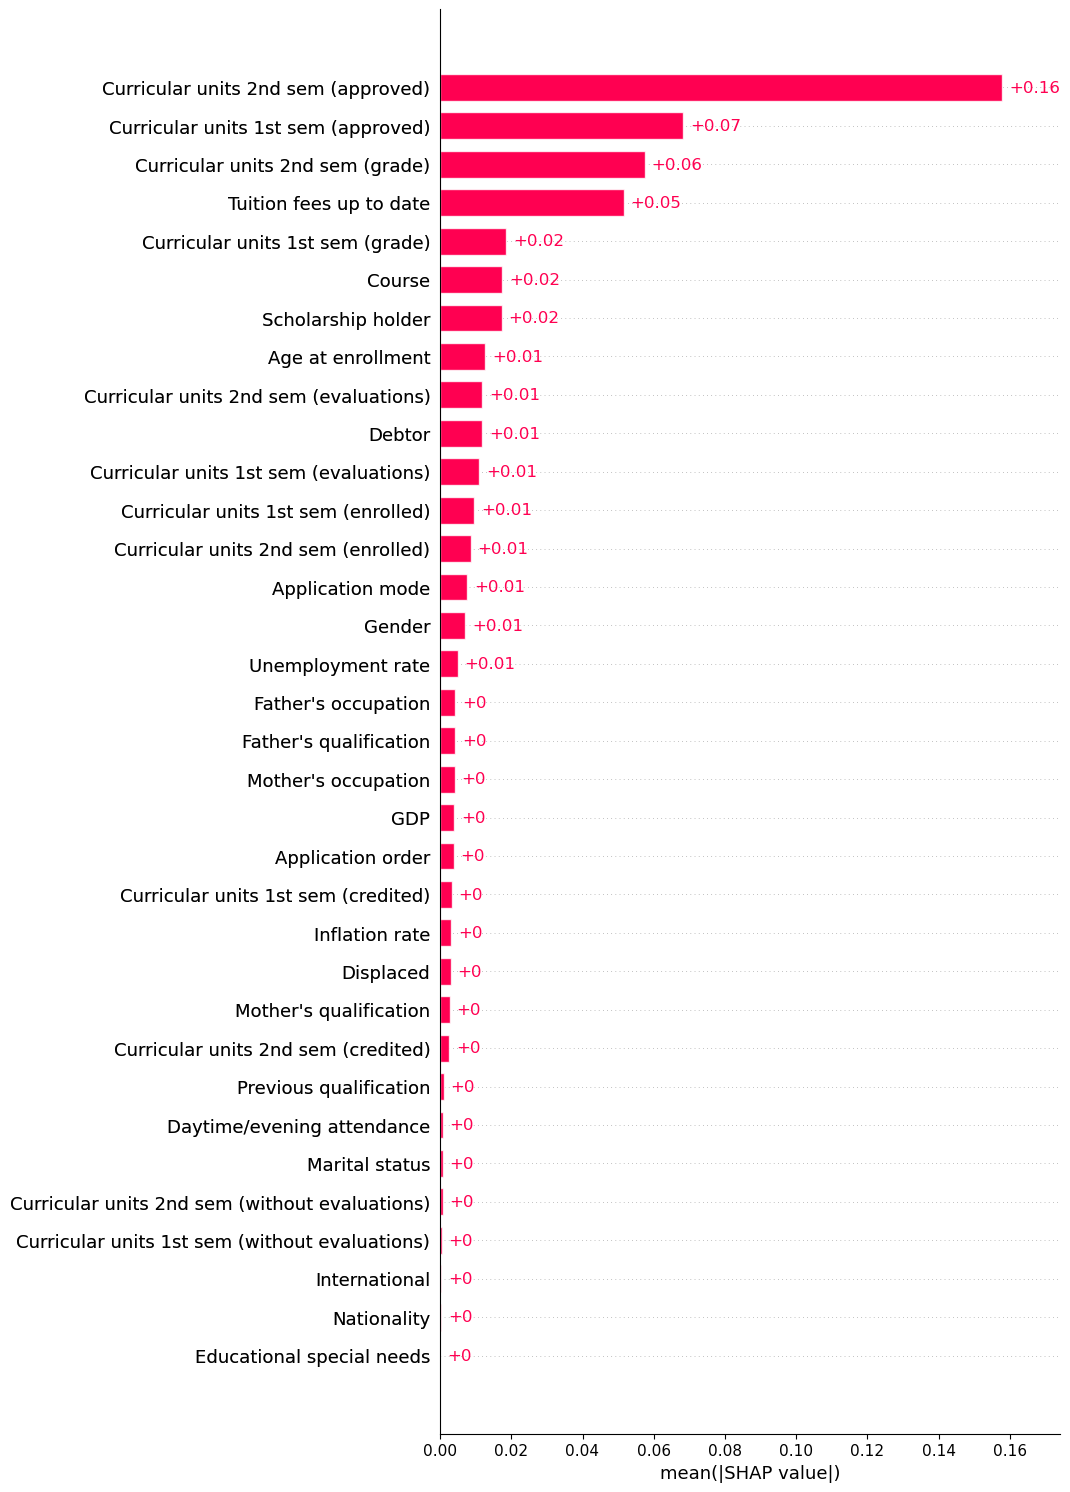

In [92]:
shap.plots.bar(shap_values[:, :, 1], max_display=34) # Make bar plot of all features

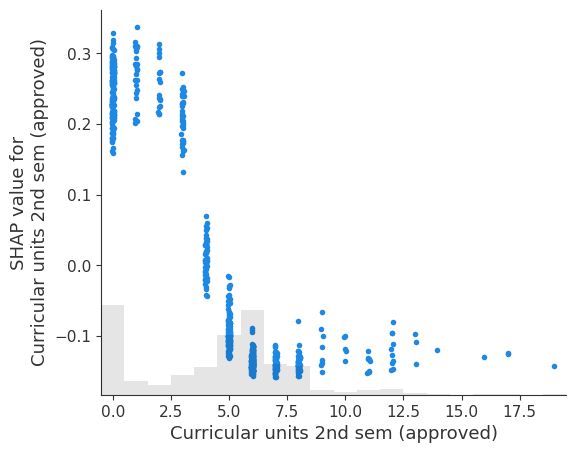

In [93]:
shap.plots.scatter(shap_values[:, "Curricular units 2nd sem (approved)", 1]) # Make scatter plot of most important feature

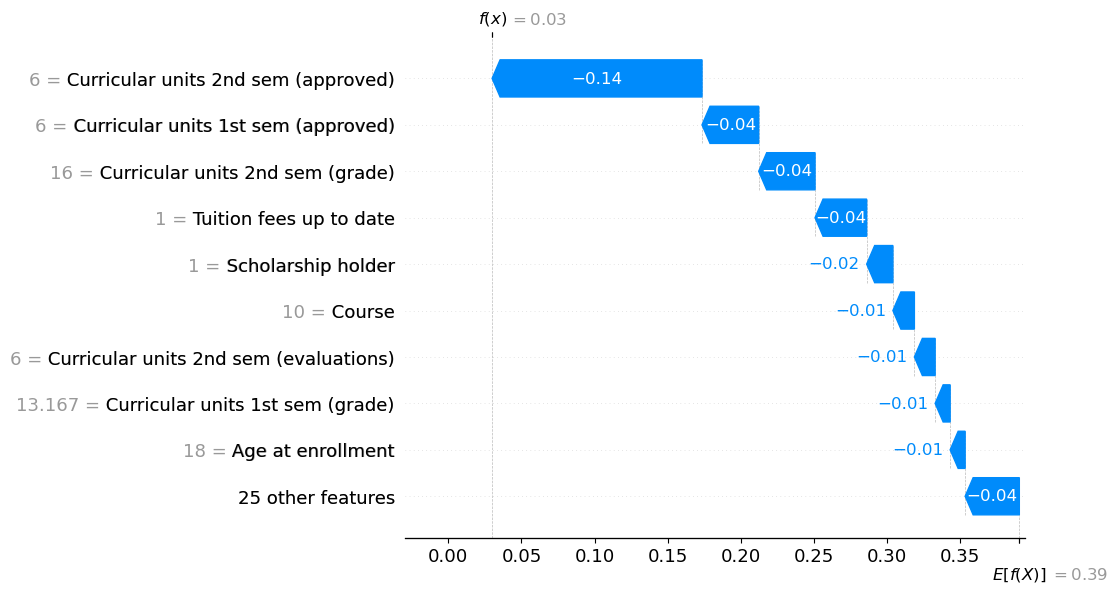

In [94]:
shap.plots.waterfall(shap_values[0, :, 1]) # Make waterfall plot of student 0

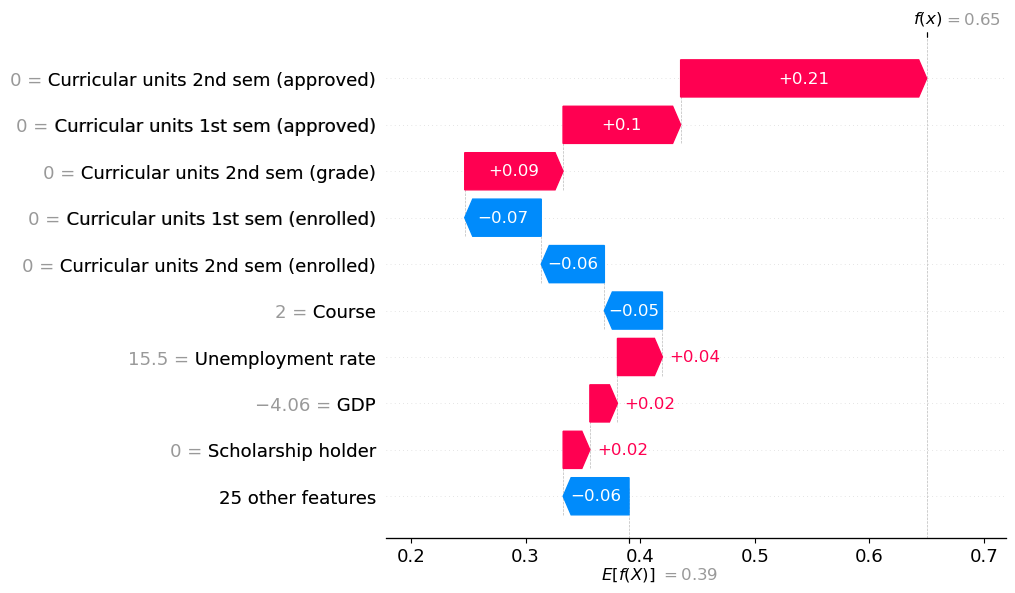

In [95]:
shap.plots.waterfall(shap_values[4, :, 1]) # Make waterfall plot of student 4

# **Counterfactuals**

In [97]:
# List all continuous features that are required for DiCE which handles continuous and categorical features differently
continuous_features = [
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

In [98]:
train_data = X_train.copy() # Make a copy of the training feature set
train_data["Target"] = y_train.values # Adds the target column back into training data

d = dice_ml.Data(dataframe=train_data, continuous_features=continuous_features, outcome_name="Target") # Creates the DiCE data interface
m = dice_ml.Model(model=rf_model, backend="sklearn") # Creates the DiCE model interface that uses a model from scikit-learn
exp = Dice(d, m, method="genetic") # Creates DiCE explainer which uses the genetic algorithm 

In [99]:
test_df = X_test.copy()
test_df["prediction"] = rf_model.predict(X_test) # Adds a new column called prediction to the test dataframe
test_df["prob"] = rf_model.predict_proba(X_test)[:, 1] # Adds the predicted dropout probability for each student

dropout_case_full = test_df[test_df["prediction"] == 1].iloc[[121]] # Selects one student which is predicted as dropout 
dropout_case = dropout_case_full[X_train.columns] # Removes the extra columns so DiCE has the same input features it was trained on
dropout_case # Displays the selected student in the notebook

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1850,1,4,1,12,1,3,1,1,1,8,11,1,0,0,0,1,0,23,0,0,7,0,0,0.0,0,0,8,0,0,0.0,0,12.7,3.7,-1.7


In [100]:
# Creates list of variables that DiCE is allowed to change
features_to_vary = [
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

In [101]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning) # Suppressing Performance warnings about dataframe fragmentation

# Generates three counterfactual explanations for graduating (opposite class of dropout) and adds a diversity weight so the counterfactuals are different from each other
cf = exp.generate_counterfactuals(dropout_case, total_CFs=3, desired_class="opposite", features_to_vary=features_to_vary, diversity_weight=1.0)
cf.visualize_as_dataframe() # Shows the original case and three generated counterfactuals in table form

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.15s/it]

Query instance (original outcome : 1)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,4,1,12,1,3,1,1,1,8,11,1,0,0,0,1,0,23,0,0,7,0,0,0.0,0,0,8,0,0,0.0,0,12.7,3.7,-1.7,1



Diverse Counterfactual set (new outcome: 0)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,4,1,12,1,3,1,1,1,8,11,1,0,0,0,1,0,23,0,0,2,0,25,0.0,0,0,10,0,17,17.0,0,12.7,3.7,-1.7,0
0,1,4,1,12,1,3,1,1,1,8,11,1,0,0,0,1,0,23,0,0,10,0,6,4.0,0,0,3,8,16,17.0,0,12.7,3.7,-1.7,0
0,1,4,1,12,1,3,1,1,1,8,11,1,0,0,0,1,0,23,0,0,0,3,11,0.0,0,0,6,7,16,17.0,0,12.7,3.7,-1.7,0


In [102]:
cf_df = cf.cf_examples_list[0].final_cfs_df 
original = dropout_case.iloc[0] # Stores original student as a single row for easier comparison

common_cols = [col for col in cf_df.columns if col in original.index] # Identify columns shared between original instance and counterfactuals

for i in range(len(cf_df)): # Iterate over each generated counterfactual
    print(f"\nCounterfactual {i+1}")
    for col in common_cols: # Compare each feature with original instance and only display features that were changed by DiCE
        if cf_df.iloc[i][col] != original[col]:
            print(f"{col}: {original[col]} -> {cf_df.iloc[i][col]}")
    print(f"New target: {cf_df.iloc[i]['Target']}") # Output the resulting predicted clas for the counterfactual (which should be 0)


Counterfactual 1
Curricular units 1st sem (enrolled): 7.0 -> 2.0
Curricular units 1st sem (approved): 0.0 -> 25.0
Curricular units 2nd sem (enrolled): 8.0 -> 10.0
Curricular units 2nd sem (approved): 0.0 -> 17.0
Curricular units 2nd sem (grade): 0.0 -> 17.0
New target: 0.0

Counterfactual 2
Curricular units 1st sem (enrolled): 7.0 -> 10.0
Curricular units 1st sem (approved): 0.0 -> 6.0
Curricular units 1st sem (grade): 0.0 -> 4.0
Curricular units 2nd sem (enrolled): 8.0 -> 3.0
Curricular units 2nd sem (evaluations): 0.0 -> 8.0
Curricular units 2nd sem (approved): 0.0 -> 16.0
Curricular units 2nd sem (grade): 0.0 -> 17.0
New target: 0.0

Counterfactual 3
Curricular units 1st sem (enrolled): 7.0 -> 0.0
Curricular units 1st sem (evaluations): 0.0 -> 3.0
Curricular units 1st sem (approved): 0.0 -> 11.0
Curricular units 2nd sem (enrolled): 8.0 -> 6.0
Curricular units 2nd sem (evaluations): 0.0 -> 7.0
Curricular units 2nd sem (approved): 0.0 -> 16.0
Curricular units 2nd sem (grade): 0.0 -> 